# Eksperimen Machine Learning System Management Lifecycle (MSML)

Nama: Muhammad Alif Aditya  
Dataset: Red Wine Quality (Cortez et al., 2009)  
Tujuan: Melakukan eksplorasi, EDA, dan preprocessing data sebagai dasar otomatisasi preprocessing.


# **1. Perkenalan Dataset**


**Sumber Dataset**:  
   Dataset yang digunakan adalah Red Wine Quality dari UCI Machine Learning Repository. Dataset ini berisi parameter kimiawi dari varian "Red Wine" dari anggur Vinho Verde Portugal. Target utamanya adalah memprediksi kualitas wine (skor 0-10) berdasarkan tes fisikokimia. Untuk eksperimen ini, kita akan mengubahnya menjadi klasifikasi biner: Good Wine (Quality >= 7) dan Bad Wine (Quality < 7).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Setting visualisasi
sns.set(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammetvarl/laptop-price")

print("Path to dataset files:", path)

/Users/macm4/repositories/MLOps-RedWine-Dashboard/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/macm4/.cache/kagglehub/datasets/muhammetvarl/laptop-price/versions/1


In [3]:
# Destination folder (change to the folder you want)
dest_dir = os.path.join(os.getcwd(), "..")
os.makedirs(dest_dir, exist_ok=True)
    
# Move / unpack depending on returned path type
if os.path.isdir(path):
    for name in os.listdir(path):
        shutil.move(os.path.join(path, name), dest_dir)
    try:
        os.rmdir(path)
    except OSError:
        pass
elif os.path.isfile(path):
    lower = path.lower()
    if lower.endswith((".zip", ".tar", ".tar.gz", ".tgz")):
        shutil.unpack_archive(path, dest_dir)
        os.remove(path)
    else:
        shutil.move(path, os.path.join(dest_dir, os.path.basename(path)))

print("Files moved/unpacked to:", dest_dir)

Files moved/unpacked to: /Users/macm4/repositories/MLOps-RedWine-Dashboard/preprocessing/..


In [2]:
df = pd.read_csv('../laptop_price.csv', encoding='latin-1')

# Menampilkan 5 baris pertama
print("5 Data Teratas:")
display(df.head())

5 Data Teratas:


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Memeriksa struktur data
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [4]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


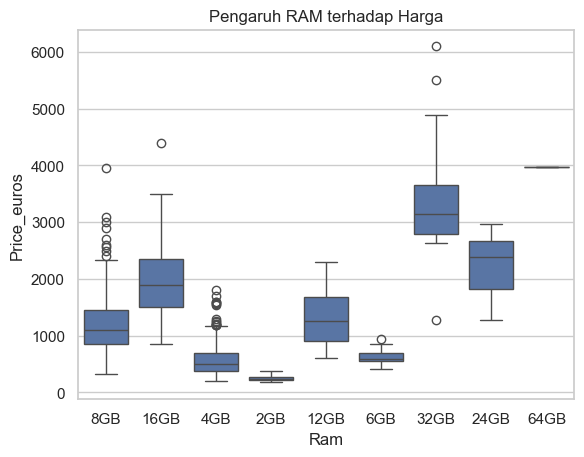

In [7]:
# Visualisasi korelasi
sns.boxplot(x='Ram', y='Price_euros', data=df)
plt.title("Pengaruh RAM terhadap Harga")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# A. Menghapus kolom yang tidak relevan (contoh: Laptop_ID)
df = df.drop(['laptop_ID'], axis=1, errors='ignore')

# B. Membuat Target Kategorikal (Binning Harga)
# Kita bagi menjadi 3 kelas: 0: Budget, 1: Mid, 2: Premium
def categorize_price(price):
    if price < 600: return 0
    elif price < 1300: return 1
    else: return 2

df['price_category'] = df['Price_euros'].apply(categorize_price)
df = df.drop('Price_euros', axis=1)

# C. Encoding Categorical Data
# Mengubah Brand, TypeName, dll menjadi angka
le = LabelEncoder()
categorical_cols = ['Company', 'TypeName', 'Cpu', 'Gpu', 'OpSys']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# C2. Normalisasi kolom numerik bertipe string (contoh: '8GB', '2.3kg')
# Ubah 'Ram' ke angka (GB)
df['Ram'] = (
    df['Ram']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Ubah 'Weight' ke angka (kg)
df['Weight'] = (
    df['Weight']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Pastikan 'Inches' numerik
df['Inches'] = pd.to_numeric(df['Inches'], errors='coerce')

# Tangani nilai kosong yang mungkin muncul setelah konversi
numerical_cols = ['Inches', 'Ram', 'Weight']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# D. Scaling Fitur Numerik
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Simpan hasil
df.to_csv('laptop_sales_preprocessed.csv', index=False)